In [1]:
import os
os.chdir('..')

# Import Files

In [ ]:
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.linear_model import LinearRegression
from arch import arch_model

from src.data_io import *

In [3]:
symbol = 'SPY'
start_date = '2000-01-03'
end_date = '2021-12-28'

params = {
    'symbol': symbol,
    'start_date': start_date,
    'end_date': end_date,
    'interval': '1d'
}
yf = YahooFinance(**params)
df = yf.pipeline()
df.head(5)

[*********************100%***********************]  1 of 1 completed


Price,date,Adj Close,Close,High,Low,Open,Volume,log_return
0,2000-01-03,91.617043,145.4375,148.25000,143.875000,148.25000,8164300,NaN
1,2000-01-04,88.034264,139.7500,144.06250,139.640625,143.53125,8089800,-0.039891
2,2000-01-05,88.191711,140.0000,141.53125,137.250000,139.93750,12177900,0.001787
3,2000-01-06,86.774391,137.7500,141.50000,137.750000,139.62500,6227200,-0.016201
4,2000-01-07,91.813911,145.7500,145.75000,140.062500,140.31250,8066500,0.056452


# Baseline Models
## Autoregressive Conditionally Heteroskedastic (ARCH) Model

ARCH(q) assumes that volatility is not fixed over time but conditioned on our current timestep, and volatility depends on previously observations. This is true as volatility have the following stylized facts:
1. **Volatility Clustering**: Periods of high/low volatility tend to cluster together.
2. **Mean Reversion**: Volatility tends to revert back to a long-run average level over time.

Assume that an asset return can be modelled by the following equation:
$$y_t = \mu + \epsilon_t$$
where $\epsilon_t = \sigma_tz_t$ and $z_t$ is i.i.d $N(0, 1)$.

$$\sigma_t^2 = \alpha_0 + \sum^q_{i=1}\alpha_i\epsilon^2_{t-i}$$
where $\sigma^2_t$ is the conditional variance of $\epsilon_t$, and all $\alpha$ coefficients are non-negative to ensure non-negative variance.

Typically, the mean of returns $\mu$ can be assumed to be 0. Alternatively, $\mu$ can be modelled through one of the ARIMA models.

Let us take the simplest case ARCH(1), we get the following equation:
$$\sigma_t^2 = \alpha_0 + \alpha_1\epsilon^2_{t-1}$$

However, there are issues with the ARCH model:
- **Ignores Persistence**: ARCH will treat model volatility as bursty (a spike up and immediate mean-reversion), where most of the time volatility is persistent and can be at elevated levels for a period of time. 
- **Number of Parameters**: In order to model persistence, we need higher order, which could lead to overfitting and instability.

## Generalized Autoregressive Conditionally Heteroskedastic (GARCH) Model
GARCH(p,q) makes the same assumption as ARCH, however it also assumes that the volatility today is affected by the volatility yesterday. This partially addresses another stylized fact of volatility:
1. **Memory**: Past volatility shocks have a lingering effect of future volatility. However, GARCH captures short-memory and leaves out long-memory.

GARCH(1,1) is essentially equivalent to ARCH($\infty$), hence we estimate significantly less parameters and achieve a more robust model:
$$\sigma^2_t = \alpha_0 + \alpha_1\epsilon^2_{t-1} + \alpha_2\epsilon^2_{t-2} + ...$$
$$\sigma^2_{t-1} = \alpha_0 + \alpha_1\epsilon^2_{t-2} + \alpha_2\epsilon^2_{t-3} + ...$$
$$\beta\sigma^2_{t-1} = \beta\alpha_0 + \beta\alpha_1\epsilon^2_{t-2} + \beta\alpha_2\epsilon^2_{t-3} + ...$$
$$\sigma^2_t - \beta\sigma^2_{t-1} = (1-\beta)\alpha_0 + \alpha_1\epsilon^2_{t-1} + (\alpha_2 - \beta\alpha_1)\epsilon^2_{t-2} + ...$$

Assuming that volatility decays exponentially, we get the following equations:
$$\alpha_2 = \beta\alpha_1, \quad \alpha_3 = \beta\alpha_2, \quad \alpha_4 = \beta\alpha_3$$
$$\alpha_k = \beta^{k-1}\alpha_1$$

Therefore, every bracketed term becomes zero, and we are left with the following equation:
$$\sigma^2_t = (1-\beta)\alpha_0 + \alpha_1\epsilon^2_{t-1} + \beta\sigma^2_{t-1}$$
$$\sigma^2_t = \omega + \alpha\epsilon^2_{t-1} + \beta\sigma^2_{t-1}$$

However, the issue is defining what is the value of the initial variance $\sigma^2_0$. Of which, our best guess is taking the expectation.
$$E[\sigma^2_t] = \omega + \alpha E[\epsilon^2_{t-1}] + \beta E[\sigma^2_{t-1}]$$

In order to find the expectation of $\epsilon^2_t$, we can try using the variance:
$$V[\epsilon_t] = E[\epsilon^2_t] - E[\epsilon_t]^2$$
$$V[\epsilon_t] = E[(\sigma_tz_t)^2] - 0$$
$$V[\epsilon_t] = E[\sigma^2_t]$$

Therefore, we get the following: 
$$E[\sigma^2_t] = \omega + \alpha E[\epsilon^2_{t-1}] + \beta E[\sigma^2_{t-1}]$$
$$E[\sigma^2_t] = \omega + \alpha E[\sigma^2_{t-1}] + \beta E[\sigma^2_{t-1}]$$
$$E[\sigma^2_t] = \omega + (\alpha+\beta) E[\sigma^2_{t-1}]$$

Lastly, since we want the unconditional mean of the conditional variance, we get:
$$\mu = \omega + (\alpha+\beta)\mu$$
$$\mu = \frac{\omega}{1-\alpha-\beta}$$

Consequently, since we assume that volatility decays exponentially, we are limiting the GARCH to model short-memory.

Mathematically, a long-memory model would have the autocorrelation of squared returns decays hyperbolically:
$$p(k) \approx k^{-d}, \quad 0 < d < 1$$
- $10^{-0.4} = 0.4$
- $100^{-0.4} = 0.16$
- $10000^{-0.4} = 0.025$

However, the autocorrelation of squared returns decays exponentially for the GARCH model:
$$p(k) \approx (\alpha + \beta)^k$$
- $0.98^{10} = 0.82$
- $0.98^{100} = 0.13$
- $0.98^{10000} \approx 0$

In [4]:
def format_yf_df(price_df:pd.DataFrame, col_name:str='Adj Close', date_format:str='%d/%m/%Y') -> pd.DataFrame:
    df = price_df.loc[:, ['date', col_name]]
    df = df.set_index('date')
    df.index = pd.to_datetime(df.index, format=date_format)
    return df

In [5]:
log_returns = format_yf_df(df, 'log_return').dropna()
log_returns.head(5)
garch = arch_model(log_returns*100, mean='constant', vol='GARCH', p=1, q=1, dist='t').fit(disp=False)
garch

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -7429.02
Distribution:      Standardized Student's t   AIC:                           14868.0
Method:                  Maximum Likelihood   BIC:                           14901.1
                                              No. Observations:                 5531
Date:                      Fri, Jan 23 2026   Df Residuals:                     5530
Time:                              13:58:32   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [6]:
garch_vol = garch.conditional_volatility/100 #rescale
garch_vol.head(5)

date
2000-01-04    0.020724
2000-01-05    0.024423
2000-01-06    0.022717
2000-01-07    0.022046
2000-01-10    0.028948
Name: cond_vol, dtype: float64

In [7]:
garch.forecast(horizon=1).variance.values[0][0]/100

np.float64(0.013908601976332702)

## Rolling GARCH
In order to account for regimes, we can do a rolling window approach. Though this is an imperfect solution, we are able to capture the local dynamics better and would suffice for comparison purposes.

In [8]:
class RollingGARCH:
    def __init__(self, log_returns_df:pd.DataFrame):
        self.df = log_returns_df.copy()
    
    def _rolling_garch(self, y:np.ndarray, window:int=1000) -> dict:
        preds, coeffs = [], []
        for k in range(window, len(y)):
            y_train = y[k-window:k]
            model = arch_model(y_train, mean='constant', vol='GARCH', p=1, q=1, dist='t').fit(disp=False)
            pred = model.forecast(horizon=1)
            pred = np.sqrt(pred.variance.values[0][0]) #Extract the number
            
            preds.append(pred)
            coeffs.append(model.params.to_dict())
        
        results = {
            'preds': preds,
            'coeffs': coeffs
        }
        return results
    
    def backtest(self, window:int=1000) -> pd.DataFrame:
        results = self._rolling_garch(self.df.values, window=window)
        coeffs = results['coeffs']
        preds = results['preds']
        
        self.eval = pd.DataFrame(coeffs)
        self.eval['preds'] = np.asarray(preds, dtype=float)
        self.eval.index = self.df.index[window:]
        return self.eval
    
    def fit(self, window:int=1000):
        self.window = window
        self.fitted_values = self.df.iloc[-window:]
        y = self.df.iloc[-window:]
        self.model = arch_model(y, mean='constant', vol='GARCH', p=1, q=1, dist='t').fit(disp=False)
    
    def forecast(self, steps:int=1) -> np.ndarray:
        if steps < 1:
            raise ValueError("Number of steps must be more than or equal to 1.")
        pred = self.model.forecast(horizon=steps)
        pred = pred.variance.iloc[-1].values.flatten()
        return np.sqrt(pred)

In [9]:
r_garch = RollingGARCH(log_returns*100)
r_garch.fit()
r_garch.fitted_values.head(5)

Price,log_return
date,
2018-01-08,0.182727
2018-01-09,0.226082
2018-01-10,-0.153114
2018-01-11,0.726983
2018-01-12,0.649774


Note that the backtest function takes a few minutes to run. Since each model fit is independent of each other, we can parallelize the code to run simultaneously to reduce the runtime to a few seconds.

In [10]:
r_garch_eval = r_garch.backtest()
r_garch_eval['preds'] /= 100
r_garch_eval.head(5)

,mu,omega,alpha[1],beta[1],nu,preds
date,,,,,,
2003-12-29,0.014753,0.028640,0.083027,0.902657,16.073835,0.007489
2003-12-30,0.018237,0.029327,0.080776,0.904652,15.471939,0.008279
2003-12-31,0.018780,0.028986,0.081581,0.903941,15.781355,0.008025
2004-01-02,0.020140,0.028058,0.081735,0.904250,15.687220,0.007772
2004-01-05,0.017805,0.025962,0.083501,0.904588,16.751115,0.007496


In [11]:
r_garch.forecast()/100

array([0.01174641])

## Optimize R-GARCH


In [12]:
class OptimizedRGARCH(RollingGARCH):
    def __init__(self, log_returns_df):
        super().__init__(log_returns_df)
    
    @staticmethod
    def _fit_predict(y_window) -> tuple[np.float64, dict]:
        model = arch_model(y_window, mean='constant', vol='GARCH', p=1, q=1, dist='t').fit(disp=False)
        pred = model.forecast(horizon=1)
        pred = np.sqrt(pred.variance.values[0][0]) #Extract the number
        coeff = model.params.to_dict()
        return (pred, coeff)
    
    def _rolling_garch(self, y, window = 1000) -> dict:
        results = Parallel(n_jobs=-2)(
            delayed(OptimizedRGARCH._fit_predict)(y[k-window:k])
            for k in range(window, len(y))
        )
        
        preds, coeffs = zip(*results)
        results = {
            'preds': preds,
            'coeffs': coeffs
        }
        return results

In [13]:
optimized_r_garch = OptimizedRGARCH(log_returns*100)
optimized_r_garch.fit()
optimized_r_garch.fitted_values.head(5)

Price,log_return
date,
2018-01-08,0.182727
2018-01-09,0.226082
2018-01-10,-0.153114
2018-01-11,0.726983
2018-01-12,0.649774


In [14]:
optimized_r_garch_eval = optimized_r_garch.backtest()
optimized_r_garch_eval['preds'] /= 100
optimized_r_garch_eval.head(5)

,mu,omega,alpha[1],beta[1],nu,preds
date,,,,,,
2003-12-29,0.014755,0.028651,0.083037,0.902643,16.076655,0.007489
2003-12-30,0.018237,0.029327,0.080776,0.904652,15.470582,0.008279
2003-12-31,0.018779,0.028984,0.081583,0.903941,15.779839,0.008025
2004-01-02,0.020140,0.028057,0.081735,0.904251,15.678349,0.007772
2004-01-05,0.017807,0.025961,0.083500,0.904590,16.746458,0.007496


In [15]:
optimized_r_garch.forecast()/100

array([0.01174641])

# Low Frequency Volatility Estimates
The paper introduced the following low-frequency realized volatility estimators:

**Parkinson Volatility**
$$P_t = \sqrt{\frac{1}{4log(2)}\left[log\left(\frac{h_t}{l_t}\right)\right]^2}$$

**Garman-Klass Volatility**
$$GK_t = \sqrt{\frac{1}{2}\left[log\left(\frac{h_t}{l_t}\right)\right]^2 - (2log(2) - 1)\left[log\left(\frac{c_t}{o_t}\right)\right]^2}$$

**Rogers-Satchell Volatility**
$$RS_t = \sqrt{log\left(\frac{h_t}{o_t}\right)log\left(\frac{h_t}{c_t}\right) + log\left(\frac{l_t}{o_t}\right)log\left(\frac{l_t}{c_t}\right)}$$

**Average of the Three**
$$RB_t = \frac{P_t + GK_t + RS_t}{3}$$
where $h_t$ is the high price, $l_t$ is the low price, $o_t$ is the opening price, and $c_t$ is the closing price.

**Below are my thoughts on the volatility measures**:

The high–low range provides a snapshot of the most extreme price movements within a day, which some could argue is sufficient to describe the intraday volatility. However, one could also argue that the open and close prices reveal how much of that intraday variation translates into a sustained price movement. As a result, combining high, low, open, and close prices could yield a more complete description of volatility than relying on the range alone.

Put in another way, volatility can be seen as the uncertainty of future outcomes. Let us take these two cases:
- Case A: $OHLC = (48, 51, 45, 48)$
- Case B: $OHLC = (45, 51, 45, 50)$

In both cases, the range is 6 (51-45), however both tell a different story in terms of uncertainty. Case A could indicate that there is equal buyer and seller pressure, hence future outcome is likely to be the same as today. Meanwhile, Case B has the stock closing near its highs, which indicates strong buyer pressure and uncertain future outcome. Will the stock hit higher highs? Will there be profit-taking which lead to lower lows? The future is more uncertain. Nonetheless, there is no right answer to which volatility measure to use. It could be the average of two measures, or perhaps the right measure appears only after applying a dimensionality reduction technique on all three. At the end of the day, it highly depends on your use-case and utility function.

In [16]:
class VolatilityMeasures:
    def __init__(self, df:pd.DataFrame):
        self.df = df.copy()
    
    def rogers_satchell_volatility(self, close:float, high:float, low:float, open:float) -> float:
        first_term = np.log(high/open)* np.log(high/close)
        second_term = np.log(low/open)* np.log(low/close)
        return np.sqrt(first_term + second_term)
    
    def garman_klass_volatility(self, close:float, high:float, low:float, open:float) -> float:
        first_term = 0.5* np.log(high/low)**2
        second_term = (2*np.log(2) - 1)* np.log(close/open)**2
        return np.sqrt(first_term - second_term)
    
    def parkinson_volatility(self, high:float, low:float) -> float:
        squared_log_hl = np.log(high/low)**2
        denom = 4*np.log(2)
        return np.sqrt(squared_log_hl/denom)
    
    def average_volatility(self, close:float, high:float, low:float, open:float) -> float:
        numerator = self.parkinson_volatility(high, low) + self.garman_klass_volatility(close, high, low, open) + self.rogers_satchell_volatility(close, high, low, open)
        return numerator/3
    
    def pipeline(self) -> pd.DataFrame:
        self.df['rogers_satchell'] = self.rogers_satchell_volatility(self.df['Close'], self.df['High'], self.df['Low'], self.df['Open'])
        self.df['garman_klass'] = self.garman_klass_volatility(self.df['Close'], self.df['High'], self.df['Low'], self.df['Open'])
        self.df['parkinson_volatility'] = self.parkinson_volatility(self.df['High'], self.df['Low'])
        self.df['average_volatility'] = self.average_volatility(self.df['Close'], self.df['High'], self.df['Low'], self.df['Open'])
        return self.df

In [17]:
lfv = VolatilityMeasures(df)
df = lfv.pipeline()
df.head(5)

Price,date,Adj Close,Close,High,Low,Open,Volume,log_return,rogers_satchell,garman_klass,parkinson_volatility,average_volatility
0,2000-01-03,91.617043,145.4375,148.25000,143.875000,148.25000,8164300,NaN,0.017988,0.017520,0.017990,0.017832
1,2000-01-04,88.034264,139.7500,144.06250,139.640625,143.53125,8089800,-0.039891,0.011567,0.014512,0.018723,0.014934
2,2000-01-05,88.191711,140.0000,141.53125,137.250000,139.93750,12177900,0.001787,0.022536,0.021718,0.018447,0.020901
3,2000-01-06,86.774391,137.7500,141.50000,137.750000,139.62500,6227200,-0.016201,0.018929,0.017032,0.016131,0.017364
4,2000-01-07,91.813911,145.7500,145.75000,140.062500,140.31250,8066500,0.056452,0.008425,0.015289,0.023905,0.015873


In [18]:
df.iloc[:, -4:].describe().round(3).T.loc[:, ['mean', '50%', 'min', 'max']]

,mean,50%,min,max
Price,,,,
rogers_satchell,0.008,0.006,0.000,0.087
garman_klass,0.008,0.006,0.001,0.082
parkinson_volatility,0.008,0.006,0.001,0.072
average_volatility,0.008,0.006,0.001,0.078


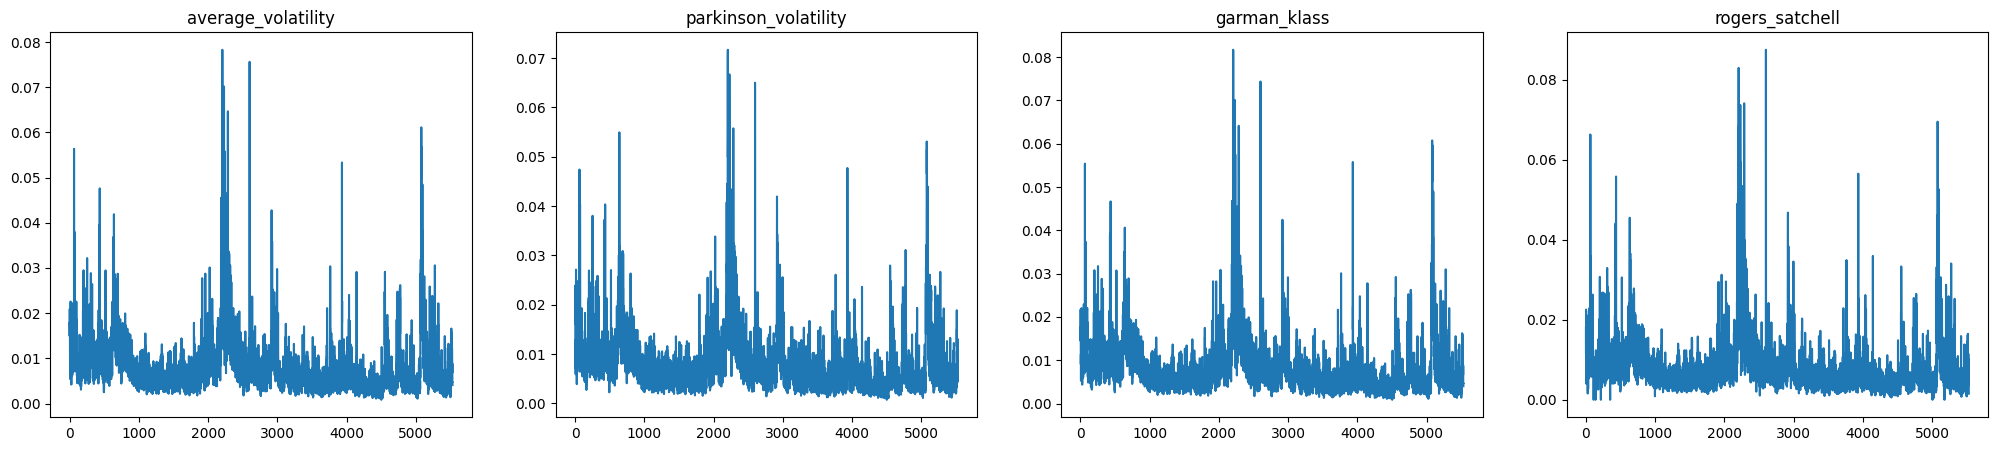

In [19]:
col_names = df.iloc[:, -4:].columns
fig, axes = plt.subplots(ncols=4, figsize=(25,5))
for i in range(1, 4+1):
    axes[i-1].plot(df.iloc[:, -i])
    axes[i-1].set_title(col_names[-i])
plt.show()

In [20]:
train_end_date = pd.Timestamp('2019-11-17')
train_df = df.loc[df['date'] < train_end_date, ['garman_klass', 'date']]
train_df.set_index('date', drop=True, inplace=True)

# Heterogeneous Autoregressive (HAR) Volatility Model

Originally, the HAR volatility model forecasts future volatility by relying on the square root of realized variance as an estimator for latent volatility. It is denoted by:
$$RV_t = \beta_0 +  \beta_1RV_{t-1} + \beta_2\frac{1}{W}\sum^W_{i=1}RV_{t-i} + \beta_3\frac{1}{M}\sum^M_{i=1}RV_{t-i} + \epsilon_t $$
where $W=5$ and $M=22$. However, this could change for cryptocurrency as the market also trades on weekends, hence we get $W=7$ and $M=30$.

In other versions of the HAR model, the log realized variance is used instead. This stabilizes the variance and bring the distribution closer to Gaussian. It is denoted by:
$$log(RV_t) = \beta_0 + \beta_1log(RV_{t-1}) + \beta_2\frac{1}{W}\sum^W_{i=1}log(RV_{t-i}) + \beta_3\frac{1}{M}\sum^M_{i=1}log(RV_{t-i}) + \epsilon_t $$

In order to calculate the high-frequency estimator, we have the following:
$$RV_t = \sqrt{\sum^K_{k=1}r^2_{t, k}}$$
where $r_{t,k}$ represents the k-th intraday return on trading day $t$.

Through the experiments detailed on the paper, they found that we can achieve a close estimate using low-frequency realized volatility estimators and seven exogenous variables. 

We shall first start off with the OLS-HAR-GarmanKlass model denoted by:
$$GK_t = \beta_0 + \beta_1GK_{t-1} + \beta_2\frac{1}{W}\sum^W_{i=1}GK_{t-i} + \beta_3\frac{1}{M}\sum^M_{i=1}GK_{t-i} + \epsilon_t $$
where $W=5$ and $M=22$.

We will also follow the methodology of model training, where we fit the model on a rolling window of 1000 to predict the next step volatility. (More details can be found in the paper.) 

## Recursive or Indirect HAR

In [21]:
class RecursiveHAR:
    def __init__(self, volatility_measure:pd.Series, weekly:int=5, monthly:int=22):
        self.data = volatility_measure.copy()
        self.days_by_period = {
            'weekly': weekly,
            'monthly': monthly
        }
        
        self.df = self._prepare_features()
    
    def _prepare_features(self) -> pd.DataFrame:
        prev_day = self.data.shift(1)
        weekly = self.data.rolling(self.days_by_period['weekly']).mean().shift(1) #current volatility cannot rely on a rolling average using its own value 
        monthly = self.data.rolling(self.days_by_period['monthly']).mean().shift(1)
        col_names = ['volatility', 'prev_day', 'weekly_rolling_avg', 'monthly_rolling_avg']
        df = pd.concat([self.data, prev_day, weekly, monthly], axis=1)
        df.columns = col_names
        return df.dropna()
    
    def _rolling_ols(self, X:np.ndarray, y:np.ndarray, window:int=1000) -> dict:
        lr = LinearRegression(fit_intercept=True)
        preds, betas, intercepts = [], [], []
        
        for k in range(window, len(y)):
            X_train = X[k-window:k] #right side excludes k-th data point
            y_train = y[k-window:k]
            model = lr.fit(X_train, y_train)
            
            X_test = X[[k]]
            y_pred = model.predict(X_test)
            preds.append(y_pred[0])
            betas.append(model.coef_)
            intercepts.append(model.intercept_)
        
        results = {
            'preds': preds,
            'betas': betas,
            'intercepts': intercepts
        }
        
        return results
    
    def backtest(self, window:int=1000) -> pd.DataFrame:
        X = self.df.iloc[:, 1:].values
        y = self.df.iloc[:, 0].values
        results = self._rolling_ols(X, y, window)
        
        #Create Dataframe
        preds = pd.Series(results['preds'], index=self.df.index[window:], name='y_hat')
        betas = pd.DataFrame(results['betas'], index=self.df.index[window:], columns=self.df.columns[1:])
        betas = betas.add_prefix("beta_")
        intercepts = pd.Series(results['intercepts'], index=self.df.index[window:], name='intercept')
        self.eval = pd.concat([betas, intercepts, preds, self.df.iloc[window:, 0]], axis=1)
        return self.eval
    
    def fit(self, window:int=1000):
        self.window = window
        self.fitted_values = self.df.iloc[-window:, 1:]
        y = self.df.iloc[-window:, 0]
        self.model = LinearRegression(fit_intercept=True).fit(self.fitted_values.values, y.values)
    
    def _process_next_day_features(self, latest_data:np.ndarray) -> np.ndarray:
        prev_day = latest_data[-1]
        weekly = latest_data[-self.days_by_period['weekly']:].mean()
        monthly = latest_data[-self.days_by_period['monthly']:].mean()
        return np.array([[prev_day, weekly, monthly]]) #(1, 3)
    
    def forecast(self, steps:int=1) -> np.ndarray:
        if steps < 1:
            raise ValueError("Number of steps must be more than or equal to 1.")
        
        latest_data = self.data.iloc[-self.days_by_period['monthly']:].values.flatten()
        preds = []
        for _ in range(steps):
            X = self._process_next_day_features(latest_data)
            pred = self.model.predict(X)[0]
            preds.append(pred)
            
            #Update latest data
            latest_data[:-1] = latest_data[1:]
            latest_data[-1] = pred
        
        return np.array(preds)
    
    @property
    def mse(self) -> float:
        if not hasattr(self, "eval"):
            raise ValueError("Evaluate the model using .backtest() before calling this method.")
        
        squared_error = (self.eval.iloc[:, -1] - self.eval.iloc[:, -2])**2
        mse = squared_error.mean()
        return mse

In [22]:
har = RecursiveHAR(train_df)
har.fit()

print(f"Coefficients: {har.model.coef_}")
har.fitted_values.head(5)

Coefficients: [0.35523067 0.39606754 0.1101328 ]


,prev_day,weekly_rolling_avg,monthly_rolling_avg
date,,,
2015-11-27,0.002407,0.004256,0.005229
2015-11-30,0.003152,0.004311,0.005192
2015-12-01,0.003208,0.004106,0.005000
2015-12-02,0.004439,0.004024,0.005052
2015-12-03,0.006993,0.004040,0.005158


In [23]:
eval = har.backtest()
print(f"MSE: {har.mse}")
eval.head(5)

MSE: 1.5433046484905073e-05


,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,intercept,y_hat,volatility
date,,,,,,
2004-01-29,0.045549,0.510652,0.299441,0.001545,0.007919,0.008046
2004-01-30,0.045105,0.511716,0.298933,0.001545,0.008187,0.003922
2004-02-02,0.044880,0.511661,0.301424,0.001520,0.007506,0.009572
2004-02-03,0.042835,0.514716,0.300182,0.001530,0.008314,0.004344
2004-02-04,0.040863,0.514081,0.304473,0.001514,0.007534,0.005563


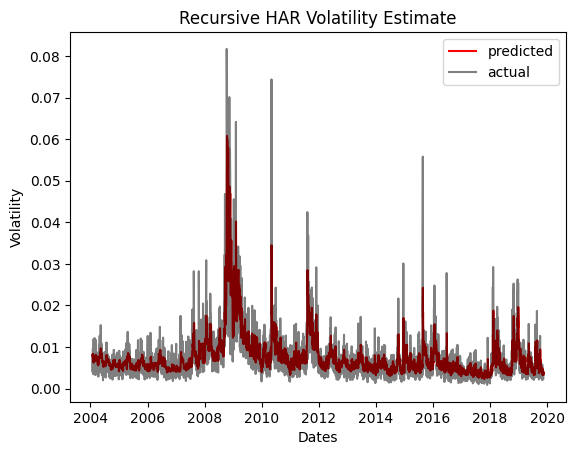

In [24]:
def plot_volatility_estimate(pred, actual, title) -> plt.Figure:
    plt.plot(pred, color='red', label='predicted')
    plt.plot(actual, color='black', alpha=0.5, label='actual')
    plt.title(title)
    plt.ylabel("Volatility")
    plt.xlabel("Dates")
    plt.legend()
    fig = plt.gcf()
    return fig

fig = plot_volatility_estimate(har.eval['y_hat'], har.eval['volatility'], 'Recursive HAR Volatility Estimate')
plt.show()

In [25]:
har.forecast(5)

array([0.00360686, 0.00384196, 0.00389086, 0.00393863, 0.00401668])

## Optimize HAR

Since each training window is independent of the results from the others, we can parallelize that code. 

This requires us to separate the worker function and reduce object copying overhead by slicing NumPy arrays instead of Pandas Dataframe. For safety reasons, we will use "n_jobs=-2".

Based on the processing time, we do not see any improvement. On the contrary, the computational efficiency got slower. This is likely due to the small number of features and each task is small at 1000 observations, hence the fixed costs dominate.

In [26]:
class OptimizedRecursiveHAR(RecursiveHAR):
    def __init__(self, volatility_measure:pd.Series, weekly:int=5, monthly:int=22):
        super().__init__(volatility_measure, weekly, monthly)
    
    @staticmethod
    def _fit_predict(X_window, y_window, X_test_row) -> tuple[float, np.ndarray, float]:
        model = LinearRegression().fit(X_window, y_window)
        return model.predict(X_test_row)[0], model.coef_, model.intercept_
    
    def _rolling_ols(self, X:np.ndarray, y:np.ndarray, window:int) -> dict:
        results = Parallel(n_jobs=-2)(
            delayed(OptimizedRecursiveHAR._fit_predict)(
                X[k - window:k],
                y[k - window:k],
                X[[k]]
            )
            for k in range(window, len(y))
        )
        preds, betas, intercepts = zip(*results)
        
        results = {
            'preds': preds,
            'betas': betas,
            'intercepts': intercepts
        }
        
        return results

In [27]:
o_har = OptimizedRecursiveHAR(df['garman_klass'])
o_eval = o_har.backtest()
o_eval.head(5)

,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,intercept,y_hat,volatility
1022,0.045549,0.510652,0.299441,0.001545,0.007919,0.008046
1023,0.045105,0.511716,0.298933,0.001545,0.008187,0.003922
1024,0.044880,0.511661,0.301424,0.001520,0.007506,0.009572
1025,0.042835,0.514716,0.300182,0.001530,0.008314,0.004344
1026,0.040863,0.514081,0.304473,0.001514,0.007534,0.005563


## Direct Forecasting
After checking my multistep forecast results with the forecast results from their Shiny app, I realized that my implementation of the forecast methodology is different from what was written. In this section, we will amend the HAR model to be aligned with the paper.

Instead of recursively feeding forecasted values back into the regressor, we redefine the dependent variable as a rolling average.
$$y_t^{(h)} = \frac{1}{h}\sum^{h}_{i=1}RV_{t+i}$$
where $t$ is the current timestep and $h$ is the forecast horizon.

For example, if we want one-week-ahead forecast, we get the following:
$$y_t^{(5)} = \frac{1}{5}\sum^{5}_{i=1}RV_{t+i}$$

Of which, we will shift that new target back to timestep $t$ or equivalently backwards by $h-1$ steps.

In [28]:
class DirectHAR(RecursiveHAR):
    def __init__(self, volatility_measure:pd.Series, weekly:int=5, monthly:int=22):
        super().__init__(volatility_measure, weekly, monthly)
    
    def _build_target(self, horizon:int) -> pd.Series:
        """Redefine the dependent variable as the future h-average volatility"""
        if horizon < 1:
            raise ValueError("Horizon must be more than or equal to 1.")
        
        new_target = self.data.rolling(horizon).mean()
        new_target = new_target.shift(-horizon+1) #Use the data today, to predict the average h-day future volatility
        return new_target.dropna()
    
    def backtest(self, horizon:int, window:int=1000) -> pd.DataFrame:
        target = self._build_target(horizon=horizon)
        df = self.df.iloc[:, 1:].join(target, how="inner") #Align Index
        
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]
        y.name = 'target'
        results = self._rolling_ols(X.values, y.values, window)
        
        #Create Dataframe
        betas = pd.DataFrame(results['betas'], index=X.index[window:], columns=X.columns).add_prefix("beta_")
        intercepts = pd.Series(results['intercepts'], index=X.index[window:], name='intercept')
        preds = pd.Series(results['preds'], index=X.index[window:], name='y_hat')
        self.eval = pd.concat([betas, intercepts, preds, y.iloc[window:]], axis=1)
        return self.eval
    
    def fit(self, horizon:int, window:int=1000):
        """
        Fit the HAR model on the latest window. If we are forecasting for more than one timestep, the target will be redefined to be the future h-average volatility.
            
        Alignment logic:
            - Features X are built from rows up to time t
            - Targets y correspond to outcomes at time t + h
            - To avoid look-ahead bias, the effective training window must be shifted backward by (horizon - 1) observations.
        
        Input:
            horizon: Forecast horizon, where 1 is the standard one-step, and 5 is the 5-day future-averaged target.
            window: Number of aligned observations used for the rolling estimation window.
        """
        start_pt = -window-(horizon-1)
        X = self.df.iloc[start_pt:-horizon+1, 1:] if horizon > 1 else self.df.iloc[start_pt:, 1:]
        y = self._build_target(horizon)
        y.columns = ['target']
        self.fitted_values = X.join(y, how='inner').dropna()
        self.model = LinearRegression(fit_intercept=True).fit(X.values, self.fitted_values['target'].values)
    
    def forecast(self) -> np.ndarray[float]:
        """Uses the latest data and the fitted regressors to predict the next h-day average volatility."""
        X = self.df.iloc[[-1], 1:].values
        pred = self.model.predict(X)[0]
        return pred

In [29]:
d_har = DirectHAR(train_df)
d_har.fit(horizon=5)
d_har.fitted_values.head(5)

,prev_day,weekly_rolling_avg,monthly_rolling_avg,target
date,,,,
2015-11-20,0.002879,0.005637,0.005483,0.004311
2015-11-23,0.004233,0.005399,0.005441,0.004106
2015-11-24,0.004847,0.004997,0.005177,0.004024
2015-11-25,0.006917,0.004931,0.005238,0.004040
2015-11-27,0.002407,0.004256,0.005229,0.005863


In [30]:
d_har.forecast()

np.float64(0.003855597649539272)

In [31]:
d_eval = d_har.backtest(horizon=5)
print(f"MSE: {d_har.mse}")
d_eval.head(5)

MSE: 8.085855298902904e-06


,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,intercept,y_hat,target
date,,,,,,
2004-01-29,0.064247,0.492331,0.247246,0.002107,0.008233,0.006289
2004-01-30,0.061288,0.497769,0.246364,0.002093,0.008411,0.005630
2004-02-02,0.060806,0.499071,0.247426,0.002076,0.007691,0.006330
2004-02-03,0.060203,0.499621,0.248434,0.002068,0.008549,0.005101
2004-02-04,0.059391,0.498773,0.251419,0.002052,0.007690,0.005124


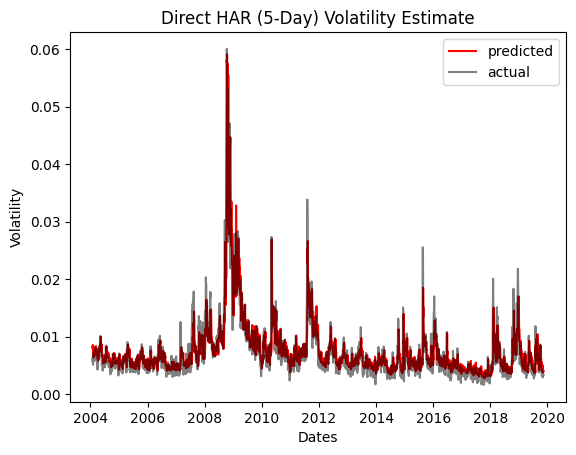

In [32]:
fig = plot_volatility_estimate(d_har.eval['y_hat'], d_har.eval['target'], 'Direct HAR (5-Day) Volatility Estimate')
plt.show()

# HAR-X Model
## Exogenous Variables
The paper proposes the following seven exogenous variables:
1. **VIX**: Market expectation of future volatility implied by prices of SPX puts and calls.

2. **US Equity Market Uncertainty (EMU)**: Number of articles in US newspapers that contain at least one term from each of three sets of terms related to economic policy uncertainty.
3. **US Economic Policy Uncertainty (EPU)**: Similar to (2) but related to equity market uncertainty.
4. **Geopolitical Risk (GPR)**:  Articles in major US newspapers covering geopolitical tensions.
5. **Aruoba-Diebold-Scotti (ADS)**: Baseline is 0, above means good business conditions and vice versa.
6. **Asset-specific one-month price momentum**: One-month change in asset prices.
7. **Asset-specific three-month price momentum**: Three-month change in asset prices.

It is recommended to download the dataset from the sources below. A simple data cleaning was done by removing unnecessary columns and only keeping the date and index value columns.

Sources:
- Yahoo Finance (1, 6, 7)
- https://www.policyuncertainty.com/equity_uncert.html (2)
- https://www.policyuncertainty.com/us_monthly.html (3)
- https://www.matteoiacoviello.com/gpr.htm (4)
- https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/ads (5)

## Feature Creation

In [33]:
tmp_dfs = []
for exo_data_file in os.listdir('./dataset'):
    if not exo_data_file.endswith('.csv'):
        continue
    
    name = os.path.join('./dataset', exo_data_file)
    tmp = pd.read_csv(name, index_col='date', thousands=',')
    tmp.index = pd.to_datetime(tmp.index, format='%d/%m/%Y')
    tmp_dfs.append(tmp)

In [34]:
def momentum_features(df:pd.DataFrame, window:int=22) -> pd.DataFrame:
    monthly_log_price = np.log(df[['Adj Close']])
    monthly_log_price.columns = [f'{window}_momentum']
    return monthly_log_price.diff(window)

momentum_df = format_yf_df(df)
one_month_momentum = momentum_features(momentum_df, 22)
three_month_momentum = momentum_features(momentum_df, 66)
tmp_dfs.extend([one_month_momentum, three_month_momentum])

In [35]:
params = {
    'symbol': '^VIX',
    'start_date': start_date,
    'end_date': end_date,
    'interval': '1d'
}
vix_yf = YahooFinance(**params)
vix_df = vix_yf.pipeline()
vix = format_yf_df(vix_df)
vix.columns = ['vix']
tmp_dfs.extend([vix])

[*********************100%***********************]  1 of 1 completed


In [36]:
exo_df = pd.concat(tmp_dfs, axis=1).dropna()
exo_df.index = pd.to_datetime(exo_df.index, format='%d/%m/%Y')
exo_df = exo_df.sort_index(ascending=True)
exo_df.head(5)

,ADS_Index,daily_equity_index,daily_policy_index,GPRD,22_momentum,66_momentum,vix
date,,,,,,,
2000-04-06,0.651701,23.08,180.20,26.67,0.096074,0.036651,27.150000
2000-04-07,0.654903,38.90,39.52,44.92,0.103644,0.082857,24.389999
2000-04-10,0.656905,17.81,47.49,36.20,0.070910,0.077141,25.990000
2000-04-11,0.654365,46.43,29.48,65.56,0.073344,0.090438,27.250000
2000-04-12,0.650136,76.83,14.63,51.27,0.056523,0.006177,28.980000


## Performance Results

In [37]:
class DirectHARX(DirectHAR):
    """
    Ensure that the index of volatility_measure and exo_df are both of datetime type.
    """
    def __init__(self, volatility_measure:pd.DataFrame, exo_df:pd.DataFrame, weekly:int=5, monthly:int=22):
        super().__init__(volatility_measure, weekly, monthly)
        self.df = pd.concat([self.df, exo_df], axis=1).dropna()

In [38]:
d_harx = DirectHARX(train_df, exo_df)
d_harx.fit(horizon=5)
d_harx.fitted_values.head(5)

,prev_day,weekly_rolling_avg,monthly_rolling_avg,ADS_Index,daily_equity_index,daily_policy_index,GPRD,22_momentum,66_momentum,vix,target
date,,,,,,,,,,,
2015-11-20,0.002879,0.005637,0.005483,-0.787966,64.03,48.78,212.19,0.036291,0.009927,15.47,0.004311
2015-11-23,0.004233,0.005399,0.005441,-0.788989,12.18,13.92,170.01,0.018392,0.029882,15.62,0.004106
2015-11-24,0.004847,0.004997,0.005177,-0.787442,9.45,28.80,246.84,0.008828,0.061785,15.93,0.004024
2015-11-25,0.006917,0.004931,0.005238,-0.784836,7.66,20.42,247.62,0.011145,0.104660,15.19,0.004040
2015-11-27,0.002407,0.004256,0.005229,-0.776446,9.88,45.15,237.59,0.014226,0.117644,15.12,0.005863


In [39]:
d_harx.forecast()

np.float64(0.0037435014382639024)

In [40]:
dx_eval = d_harx.backtest(horizon=5)
print(f"MSE: {d_harx.mse}")
dx_eval.head(5)

MSE: 5.757907896970211e-06


,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,beta_ADS_Index,beta_daily_equity_index,beta_daily_policy_index,beta_GPRD,beta_22_momentum,beta_66_momentum,beta_vix,intercept,y_hat,target
date,,,,,,,,,,,,,
2004-04-01,0.000585,0.258226,0.031273,0.000664,0.000002,2.697044e-07,-0.000004,-0.010057,-0.005449,0.000292,0.000834,0.006940,0.004267
2004-04-02,-0.000879,0.266153,0.026736,0.000671,0.000002,3.249165e-07,-0.000004,-0.009822,-0.005403,0.000294,0.000784,0.006239,0.005332
2004-04-05,-0.000516,0.265319,0.026706,0.000666,0.000002,3.322743e-07,-0.000004,-0.009831,-0.005394,0.000294,0.000777,0.005969,0.004756
2004-04-06,0.005386,0.248531,0.031140,0.000625,0.000002,3.161020e-07,-0.000004,-0.010131,-0.005517,0.000293,0.000835,0.006105,0.005733
2004-04-07,0.009797,0.228612,0.039685,0.000578,0.000002,3.972662e-07,-0.000004,-0.010592,-0.005736,0.000290,0.000945,0.006232,0.006107


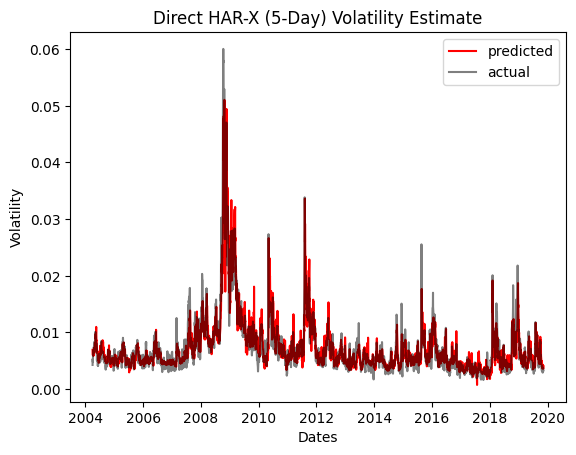

In [41]:
fig = plot_volatility_estimate(d_harx.eval['y_hat'], d_harx.eval['target'], 'Direct HAR-X (5-Day) Volatility Estimate')
plt.show()